<a href="https://colab.research.google.com/github/yiding2022/DAAI/blob/main/Day2_Estimation_of_Linear_Relationship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day2: Estimation of Linear Models

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import scipy.stats

In [ ]:
from google.colab import files

# Upload file
uploaded = files.upload()

In [3]:
url = "https://raw.githubusercontent.com/yiding2022/DAAI/main/MASchools.csv"
MASchools = pd.read_csv(url)

In [4]:
MASchools

,district,municipality,expreg,expspecial,expbil,expocc,exptot,scratio,special,lunch,stratio,income,score4,score8,salary,english
0,1,Abington,4201,7375.689941,0,0,4646,16.600000,14.600000,11.800000,19.000000,16.379,714,691.0,34.360001,0.000000
1,2,Acton,4129,8573.990234,0,0,4930,5.700000,17.400000,2.500000,22.600000,25.792,731,NaN,38.063000,1.246106
2,3,Acushnet,3627,8081.720215,0,0,4281,7.500000,12.100000,14.100000,19.299999,14.040,704,693.0,32.491001,0.000000
3,5,Agawam,4015,8181.370117,0,0,4826,8.600000,21.100000,12.100000,17.900000,16.111,704,691.0,33.105999,0.322581
4,7,Amesbury,4273,7037.220215,0,0,4824,6.100000,16.799999,17.400000,17.500000,15.423,701,699.0,34.436501,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215,344,Winchester,5631,9549.150391,0,0,6264,6.800000,11.100000,3.300000,16.900000,30.615,737,730.0,NaN,0.787402
216,346,Winthrop,3986,8068.390137,0,0,4805,12.500000,20.900000,16.600000,16.600000,17.850,704,696.0,NaN,2.512563
217,347,Woburn,4945,8069.970215,0,0,5712,17.200001,16.200001,16.900000,18.400000,18.155,721,709.0,NaN,0.000000
218,348,Worcester,4545,9719.620117,6541,2951,5727,8.300000,17.799999,45.700001,16.600000,13.393,693,664.0,35.615501,3.080082


In [5]:
# understand data
MASchools.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   district      220 non-null    int64  
 1   municipality  220 non-null    object 
 2   expreg        220 non-null    int64  
 3   expspecial    220 non-null    float64
 4   expbil        220 non-null    int64  
 5   expocc        220 non-null    int64  
 6   exptot        220 non-null    int64  
 7   scratio       211 non-null    float64
 8   special       220 non-null    float64
 9   lunch         220 non-null    float64
 10  stratio       220 non-null    float64
 11  income        220 non-null    float64
 12  score4        220 non-null    int64  
 13  score8        180 non-null    float64
 14  salary        195 non-null    float64
 15  english       220 non-null    float64
dtypes: float64(9), int64(6), object(1)
memory usage: 27.6+ KB


In [6]:
MASchools.describe()
# missing values observed for scratio, score8, and salary

# score 4 - 4th grade score
# exptot - expenditure per pupil, total
# scatio - student per computer
# special - special education students (%)
# stratio - student per teacher ratio
# salary - average teacher salary

,district,expreg,expspecial,expbil,expocc,exptot,scratio,special,lunch,stratio,income,score4,score8,salary,english
count,220.000000,220.000000,220.000000,220.000000,220.000000,220.000000,211.000000,220.000000,220.000000,220.000000,220.000000,220.000000,180.000000,195.000000,220.000000
mean,170.936364,4605.463636,8900.726773,3037.309091,1104.209091,5370.250000,8.107109,15.967727,15.315909,17.344091,18.746764,709.827273,698.411111,35.992697,1.117676
std,102.788321,880.252436,3511.696142,20259.258149,2732.448792,977.040427,2.835993,3.538000,15.060068,2.276666,5.807637,15.126474,21.052684,3.190556,2.900940
min,1.000000,2905.000000,3832.229980,0.000000,0.000000,3465.000000,2.300000,8.100000,0.400000,11.400000,9.686000,658.000000,641.000000,24.965000,0.000000
25%,84.500000,4065.000000,7442.300171,0.000000,0.000000,4730.250000,6.100000,13.375000,5.300000,15.800000,15.223000,701.000000,685.000000,33.800749,0.000000
50%,163.500000,4488.500000,8353.790039,0.000000,0.000000,5155.000000,7.800000,15.450000,10.550000,17.100000,17.128000,711.000000,698.000000,35.883999,0.000000
75%,269.250000,4971.750000,9721.922607,0.000000,0.000000,5788.750000,9.800000,17.925000,20.025000,19.025000,20.376000,720.000000,712.000000,37.957001,0.885939
max,350.000000,8759.000000,53569.238281,295140.000000,15088.000000,9868.000000,18.400000,34.299999,76.199997,27.000000,46.855000,740.000000,747.000000,44.493999,24.493927


In [7]:
# investigate linear relationship: score4 ~ exptot + scatio + special + stratio + salary

df = MASchools.iloc[:, [12, 6,7,8,10,14]].copy()
print(df.shape)
df.head(7).round(2)

(220, 6)


,score4,exptot,scratio,special,stratio,salary
0,714,4646,16.6,14.6,19.0,34.36
1,731,4930,5.7,17.4,22.6,38.06
2,704,4281,7.5,12.1,19.3,32.49
3,704,4826,8.6,21.1,17.9,33.11
4,701,4824,6.1,16.8,17.5,34.44
5,714,6454,7.7,17.2,15.7,NaN
6,725,5537,5.4,11.3,17.1,41.62


In [8]:
# detect % of missing values in each variable used
df.isna().mean()*100

,0
score4,0.000000
exptot,0.000000
scratio,4.090909
special,0.000000
stratio,0.000000
salary,11.363636


In [9]:
num_na = df.isna().any(axis=1).sum() # no of rows with any NAs
num_complete = len(df) - num_na # complement
print("True: ",num_na, "False: ", num_complete)

True:  34 False:  186


In [10]:
salarymean = df['salary'].mean()
salaryimputed = df['salary'].fillna(salarymean)
print(salarymean)
print(salaryimputed.mean())
print(df['salary'].std())
print(salaryimputed.std())

35.992697446774216
35.992697446774216
3.1905555712426232
3.0029293928495764


In [11]:
df1 = df.dropna().copy() # copy is needed to make future assignments safe
print(len(df))
len(df1)

220


186

# Multicollinearity

<Axes: >

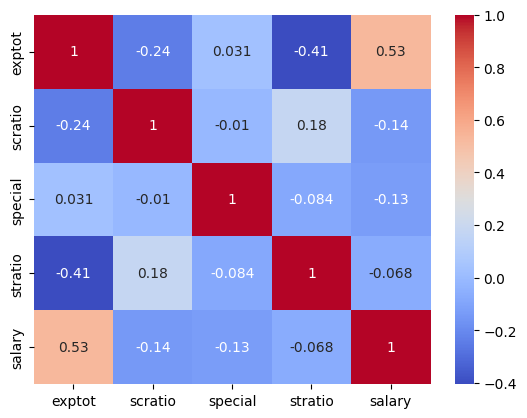

In [12]:
import seaborn as sns

# Select the independent variables
independent_vars = df1[['exptot', 'scratio', 'special', 'stratio', 'salary']]

# Calculate the correlation matrix
corr_matrix = independent_vars.corr()

# Plot the correlation heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')


In [13]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select the independent variables
X = df1[['exptot', 'scratio', 'special', 'stratio', 'salary']]

# Calculate VIF for each independent variable
vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

# Print the VIF values
print(vif)

overall_vif = vif["VIF"].mean()

print(overall_vif)



  Variable         VIF
0   exptot   63.496643
1  scratio    9.895906
2  special   18.805538
3  stratio   52.801204
4   salary  140.579749
57.115807806526824


## Linear Regression Model

### Regression Functions in R and Python

In [14]:
from statsmodels.formula.api import ols
res3 = ols("score4 ~ exptot + scratio + special + stratio + salary", data=df1).fit()
print(res3.summary())
import statsmodels.formula.api as smf
import statsmodels.api as sm
#res4 = smf.glm("score4 ~ exptot + scratio + special + stratio + salary", data=df1, family=sm.families.Gaussian()).fit()
#print(res4.summary())

                            OLS Regression Results                            
Dep. Variable:                 score4   R-squared:                       0.276
Model:                            OLS   Adj. R-squared:                  0.255
Method:                 Least Squares   F-statistic:                     13.69
Date:                Mon, 18 May 2026   Prob (F-statistic):           2.50e-11
Time:                        16:34:54   Log-Likelihood:                -742.49
No. Observations:                 186   AIC:                             1497.
Df Residuals:                     180   BIC:                             1516.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    714.7035     16.343     43.730      0.0

In [15]:
df1['salary2'] = df1['salary']**2
res_salary2 = ols("score4 ~ exptot + scratio + special + stratio + salary + salary2", data=df1).fit()
print(res_salary2.summary())

                            OLS Regression Results                            
Dep. Variable:                 score4   R-squared:                       0.318
Model:                            OLS   Adj. R-squared:                  0.295
Method:                 Least Squares   F-statistic:                     13.93
Date:                Mon, 18 May 2026   Prob (F-statistic):           5.62e-13
Time:                        16:34:56   Log-Likelihood:                -736.83
No. Observations:                 186   AIC:                             1488.
Df Residuals:                     179   BIC:                             1510.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    986.1153     82.504     11.952      0.0

In [16]:
df1['exptot_scratio'] = df1['exptot'] * df1['scratio']
res_interaction = ols("score4 ~ exptot + scratio + special + stratio + salary + salary2 + exptot_scratio", data=df1).fit()
print(res_interaction.summary())

                            OLS Regression Results                            
Dep. Variable:                 score4   R-squared:                       0.342
Model:                            OLS   Adj. R-squared:                  0.316
Method:                 Least Squares   F-statistic:                     13.21
Date:                Mon, 18 May 2026   Prob (F-statistic):           1.14e-13
Time:                        16:44:30   Log-Likelihood:                -733.55
No. Observations:                 186   AIC:                             1483.
Df Residuals:                     178   BIC:                             1509.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        941.9765     83.145     11.

In [18]:
# work on another dataset

url = "https://raw.githubusercontent.com/yiding2022/DAAI/main/Utilities.txt"
Utilities = pd.read_csv(url)


In [19]:
Utilities

,Company,Fixed_charge,RoR,Cost,Load_factor,Demand_growth,Sales,Nuclear,Fuel_Cost
0,Arizona,1.06,9.2,151,54.4,1.6,9077,0.0,0.628
1,Boston,0.89,10.3,202,57.9,2.2,5088,25.3,1.555
2,Central,1.43,15.4,113,53.0,3.4,9212,0.0,1.058
3,Commonwealth,1.02,11.2,168,56.0,0.3,6423,34.3,0.700
4,NY,1.49,8.8,192,51.2,1.0,3300,15.6,2.044
5,Florida,1.32,13.5,111,60.0,-2.2,11127,22.5,1.241
6,Hawaiian,1.22,12.2,175,67.6,2.2,7642,0.0,1.652
7,Idaho,1.10,9.2,245,57.0,3.3,13082,0.0,0.309
8,Kentucky,1.34,13.0,168,60.4,7.2,8406,0.0,0.862
9,Madison,1.12,12.4,197,53.0,2.7,6455,39.2,0.623


In [21]:
import numpy as np
from statsmodels.formula.api import ols

# Identify numerical columns for independent variables, excluding 'Company' and 'Sales'
numerical_cols_utilities = Utilities.select_dtypes(include=np.number).columns.tolist()
independent_vars_sales = [col for col in numerical_cols_utilities if col not in ['Sales']]

# Construct the OLS formula with 'Sales' as the dependent variable
formula_sales = "Sales ~ " + " + ".join(independent_vars_sales)

# Fit the OLS model
res_sales = ols(formula_sales, data=Utilities).fit()

# Print the summary of the regression results
print(res_sales.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.593
Model:                            OLS   Adj. R-squared:                  0.389
Method:                 Least Squares   F-statistic:                     2.913
Date:                Mon, 18 May 2026   Prob (F-statistic):             0.0421
Time:                        16:50:48   Log-Likelihood:                -200.66
No. Observations:                  22   AIC:                             417.3
Df Residuals:                      14   BIC:                             426.1
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept      1.997e+04   9668.141      2.066